# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image
# Import the library
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

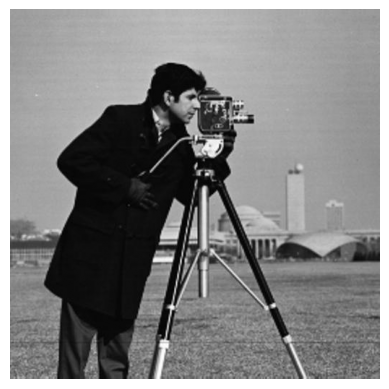

In [2]:
# ── Load image ────────────────────────────────────
image = Image.open("cameraman.jpg")
plt.imshow(image ,cmap='gray')
plt.axis('off')

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = image.size
# scaling factors
cx = 2 
cy = 2

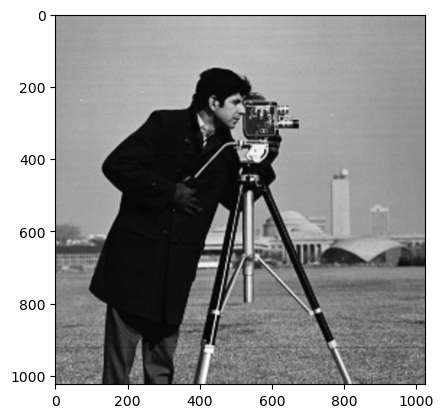

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * cx)
new_height = int(height * cy)
# Resize the image using PIL's built-in method
scaled_image = image.resize((new_width, new_height), Image.LANCZOS)
plt.imshow(scaled_image, cmap='gray')
plt.show()

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save('task1_1_scaled.jpg')
print(f"Original size: {image.size}")
print(f"New size: {scaled_image.size}")

Original size: (512, 512)
New size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx_uniform = 2
cy_uniform = 1
stretch_width = int(width * cx_uniform)
stretch_height = int(height * cy_uniform)

In [7]:
stretched_image = image.resize((stretch_width, stretch_height), Image.LANCZOS)

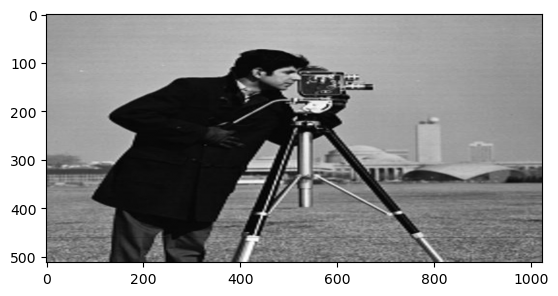

In [8]:
plt.imshow(stretched_image, cmap='gray')
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.R

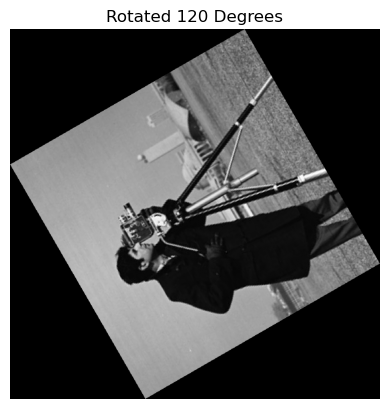

Original size: (512, 512)
New size after rotation: (700, 700)


In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image = image.rotate(120, expand=True)
rotated_image.save('task1_2_rotated.jpg')
plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated 120 Degrees")
plt.axis('off')
plt.show()
print(f"Original size: {image.size}")
print(f"New size after rotation: {rotated_image.size}")

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

In [11]:

shx = 0.5  
shy = 0    

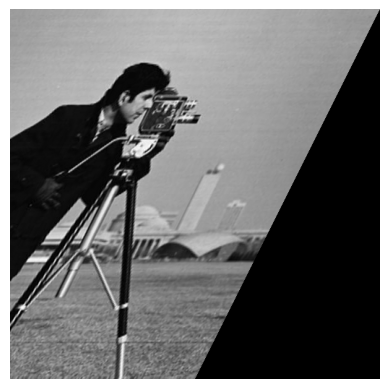

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
shx = 0.5 
shy = 0
matrix = (1, shx, 0, shy, 1, 0)
sheared_image = image.transform(image.size, Image.AFFINE, matrix, resample=Image.BICUBIC)
plt.imshow(sheared_image, cmap='gray')
plt.axis('off')
plt.show()

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save('task1_3_sheared.jpg')
print(f"Sheared image saved as task1_3_sheared.jpg")

Sheared image saved as task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

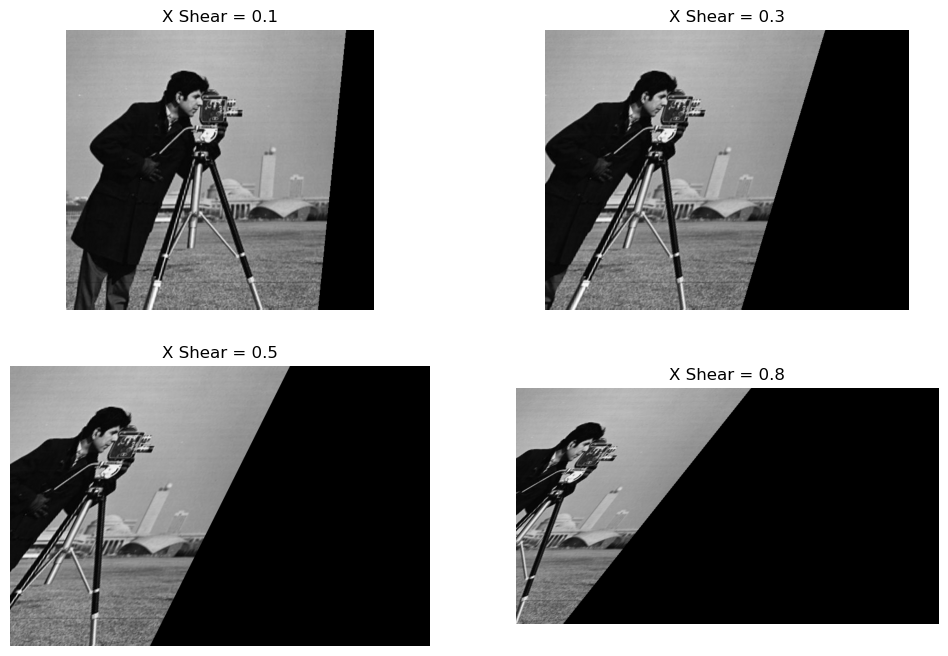

In [18]:
# Experiment and compare: X-axis shear factors
factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(12, 8))

for i, shx in enumerate(factors):
    new_width = int(width + shx * height)
    matrix = (1, shx, 0, 0, 1, 0)

    sheared = image.transform(
        (new_width, height),
        Image.AFFINE,
        matrix,
        resample=Image.BICUBIC
    )

    plt.subplot(2, 2, i + 1)
    plt.imshow(sheared, cmap='gray')
    plt.title(f"X Shear = {shx}")
    plt.axis('off')

plt.show()

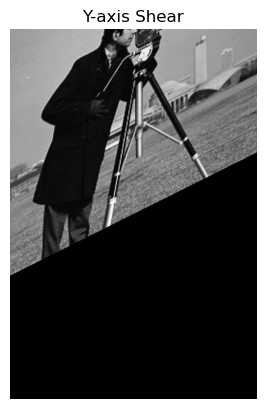

In [19]:
# Switch from X-axis to Y-axis shear matrix
shx = 0
shy = 0.5

new_height = int(height + shy * width)
matrix = (1, 0, 0, shy, 1, 0)

y_sheared = image.transform(
    (width, new_height),
    Image.AFFINE,
    matrix,
    resample=Image.BICUBIC
)

plt.imshow(y_sheared, cmap='gray')
plt.title("Y-axis Shear")
plt.axis('off')
plt.show()

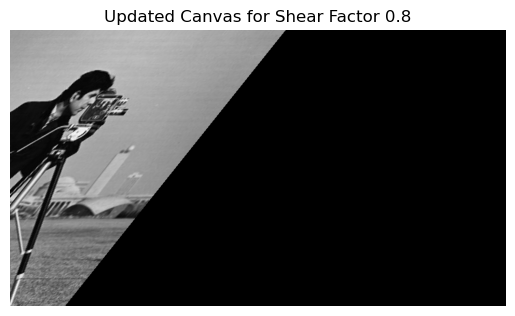

In [21]:
# Update the canvas multiplier to match the new shear factor

shx = 0.8
shy = 0

new_width = int(width + shx * height)
new_height = height

matrix = (1, shx, 0, shy, 1, 0)

updated_canvas_shear = image.transform(
    (new_width, new_height),
    Image.AFFINE,
    matrix,
    resample=Image.BICUBIC
)

plt.imshow(updated_canvas_shear, cmap='gray')
plt.title("Updated Canvas for Shear Factor 0.8")
plt.axis('off')
plt.show()

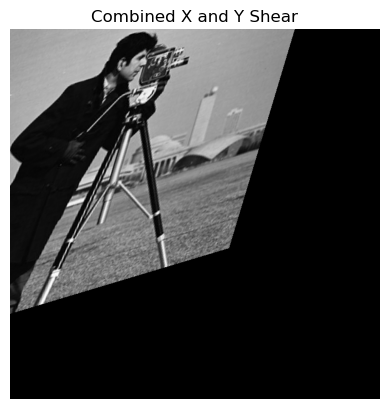

In [20]:
# Combine X and Y shear in one matrix
shx = 0.3
shy = 0.3

new_width = int(width + shx * height)
new_height = int(height + shy * width)

matrix = (1, shx, 0, shy, 1, 0)

combined_shear = image.transform(
    (new_width, new_height),
    Image.AFFINE,
    matrix,
    resample=Image.BICUBIC
)

plt.imshow(combined_shear, cmap='gray')
plt.title("Combined X and Y Shear")
plt.axis('off')
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

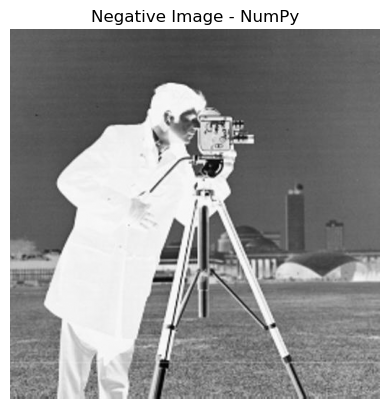

In [22]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

import numpy as np

image_array = np.array(image)

negative_array = 255 - image_array

negative_image = Image.fromarray(negative_array)

plt.imshow(negative_image, cmap='gray')
plt.title("Negative Image - NumPy")
plt.axis('off')
plt.show()




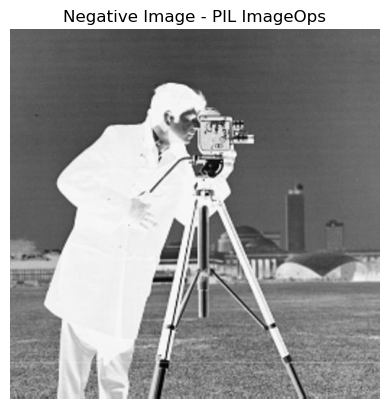

In [23]:
# Method 2: PIL's ImageOps

from PIL import ImageOps

negative_pil = ImageOps.invert(image)

plt.imshow(negative_pil, cmap='gray')
plt.title("Negative Image - PIL ImageOps")
plt.axis('off')
plt.show()

C:\Users\reema\AppData\Local\Temp\ipykernel_5560\637485967.py:9: RuntimeWarning: divide by zero encountered in log
  log_transformed = c * np.log(1 + image_array)
C:\Users\reema\AppData\Local\Temp\ipykernel_5560\637485967.py:11: RuntimeWarning: invalid value encountered in cast
  log_transformed = np.array(log_transformed, dtype=np.uint8)


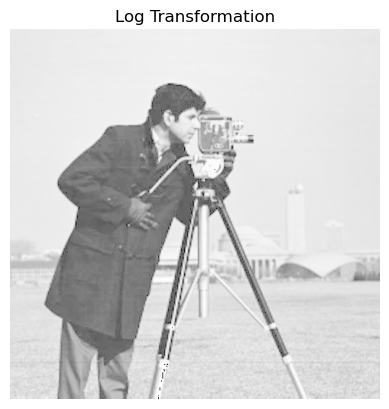

In [24]:
# ── 2. Log transformation ──────────────────────────

import numpy as np

image_array = np.array(image)

c = 255 / np.log(1 + 255)

log_transformed = c * np.log(1 + image_array)

log_transformed = np.array(log_transformed, dtype=np.uint8)

log_image = Image.fromarray(log_transformed)

plt.imshow(log_image, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()


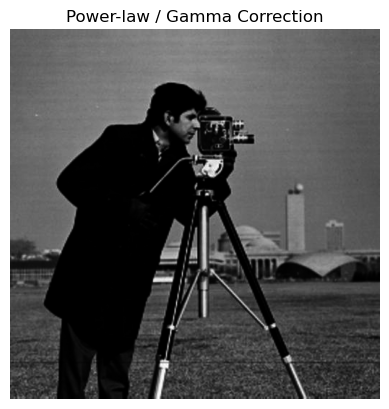

In [25]:
# ── 3. Power-law / Gamma correction ───────────────

import numpy as np

image_array = np.array(image)

# Gamma value
gamma = 2.0

# c = 1 usually, but because pixel values are 0–255,
# we normalize first, apply gamma, then scale back to 255
gamma_corrected = 255 * ((image_array / 255) ** gamma)

gamma_corrected = np.array(gamma_corrected, dtype=np.uint8)

gamma_image = Image.fromarray(gamma_corrected)

plt.imshow(gamma_image, cmap='gray')
plt.title("Power-law / Gamma Correction")
plt.axis('off')
plt.show()

In [26]:
gamma_image.save("task2_4_gamma_correction.jpg")